<a href="https://colab.research.google.com/github/abdullahhammad652-bot/Hammad/blob/main/KMeans%20clustring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
x,y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [5]:
df=pd.DataFrame(x,columns=['feature1','feature2'])

In [7]:
df

,feature1,feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [8]:
scaler = StandardScaler()
x_scaler=scaler.fit_transform(x)

In [10]:
inertia=[]
k_range=range(1,11)

In [11]:
for k in k_range:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_scaler)
    inertia.append(kmeans.inertia_)

In [12]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.774421648923889,
 9.500553029597258,
 6.961696920389017,
 6.399573756141993,
 5.70252828809694,
 5.032417712334918,
 4.858717960886742]

Text(0, 0.5, 'Inertia')

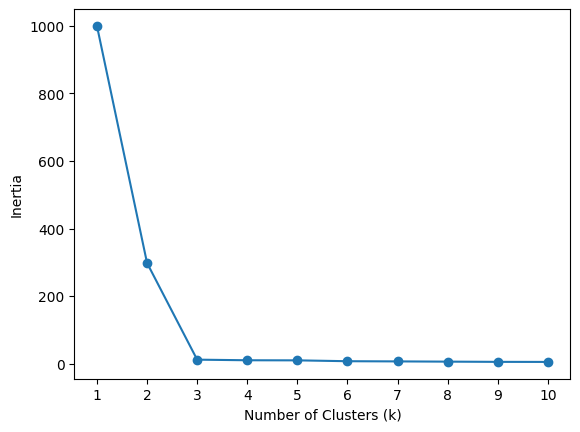

In [14]:
plt.plot(k_range,inertia,marker='o')
plt.xticks(k_range)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

In [15]:
kmeans_final=KMeans(n_clusters=3,random_state=42)

In [16]:
cluster_label=kmeans_final.fit_predict(x_scaler)

In [17]:
cluster_label

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [18]:
df['cluster']=cluster_label

<Axes: xlabel='feature1', ylabel='feature2'>

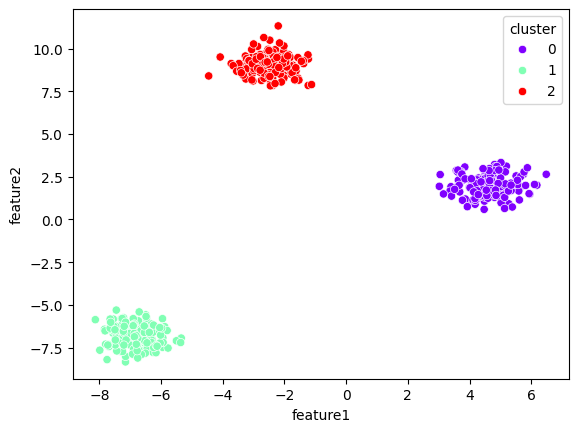

In [20]:
sns.scatterplot(x='feature1',y='feature2',data=df,hue='cluster',palette='rainbow')

In [22]:
from sklearn.datasets import make_moons

In [23]:
x,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [24]:
from sklearn.cluster import KMeans,DBSCAN

In [25]:
df=pd.DataFrame(x,columns=['feature1','feature2'])

In [26]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x)

In [27]:
KMeans=KMeans(n_clusters=2,random_state=42)

In [28]:
kmeans_labels=KMeans.fit_predict(x_scaler)

In [29]:
df['kmeans_cluster']=kmeans_labels

<Axes: xlabel='feature1', ylabel='feature2'>

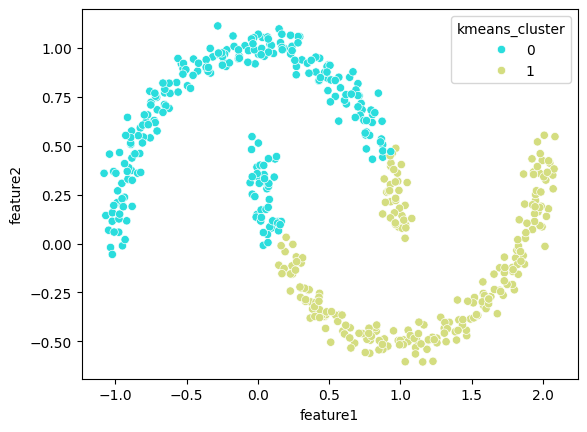

In [30]:
sns.scatterplot(x='feature1',y='feature2',data=df,hue='kmeans_cluster',palette='rainbow')

In [31]:
dbscan=DBSCAN(eps=0.3,min_samples=5)

In [32]:
dbscan_labels=dbscan.fit_predict(x_scaler)

In [34]:
df['dbscan_cluster']=dbscan_labels

<Axes: xlabel='feature1', ylabel='feature2'>

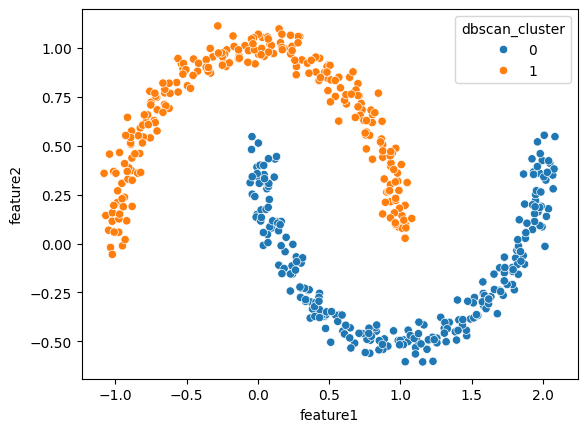

In [39]:
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue=df['dbscan_cluster'],palette='tab10')